<a href="https://colab.research.google.com/github/roboy88/Modeling-Ukraine-aid-and-Global-Charitable-vs-Military-Priorities-Through-Data/blob/main/Modeling_Ukraine_aid_and_Global_Charitable_vs_Military_Priorities_Through_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Financial Allocations.csv to Financial Allocations.csv
Saving Financial Commitments.csv to Financial Commitments.csv


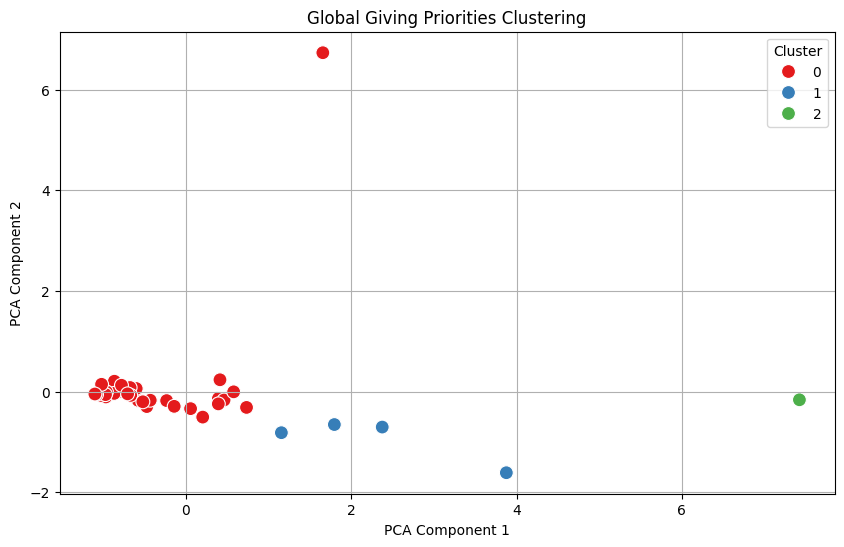

In [2]:
# === CHARITABLE GIVING vs MILITARY AID MODEL ===
# Title: The Cost of Compassion - Global Giving Priorities

# === STEP 1: IMPORT LIBRARIES ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# === STEP 2: UPLOAD FILES ===
from google.colab import files
uploaded = files.upload()  # Upload 'Financial Allocations.csv' and 'Financial Commitments.csv'

# === STEP 3: LOAD DATA ===
allocations = pd.read_csv('Financial Allocations.csv')
commitments = pd.read_csv('Financial Commitments.csv')

# === STEP 4: MERGE DATASETS ON COUNTRY ===
df = pd.merge(allocations, commitments, on=['Country', 'EU member'])

# === STEP 5: FEATURE ENGINEERING ===
df['Humanitarian_GDP_Ratio'] = df['Humanitarian commitments($ billion)'] / df['GDP in 2021($ billion)']
df['Military_GDP_Ratio'] = df['Military commitments($ billion)'] / df['GDP in 2021($ billion)']
df['Total_GDP_Ratio'] = df['Total bilateral commitments($ billion)'] / df['GDP in 2021($ billion)']
df['Humanitarian_to_Military_Ratio'] = df['Humanitarian commitments($ billion)'] / (df['Military commitments($ billion)'] + 1e-6)

# === STEP 6: CLUSTERING ===
features = df[['Humanitarian_GDP_Ratio', 'Military_GDP_Ratio', 'Total_GDP_Ratio', 'Humanitarian_to_Military_Ratio']]
scaled_features = StandardScaler().fit_transform(features)

# PCA for 2D visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# === STEP 7: VISUALIZATION ===
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=df['Cluster'], palette='Set1', s=100)
plt.title("Global Giving Priorities Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

# === STEP 8: EXPORT RESULTS ===
df[['Country', 'EU member', 'Humanitarian_GDP_Ratio', 'Military_GDP_Ratio',
    'Total_GDP_Ratio', 'Humanitarian_to_Military_Ratio', 'Cluster']].to_csv("Global_Charity_Clusters.csv", index=False)


Saving Financial Allocations.csv to Financial Allocations (1).csv
Saving Financial Commitments.csv to Financial Commitments (1).csv


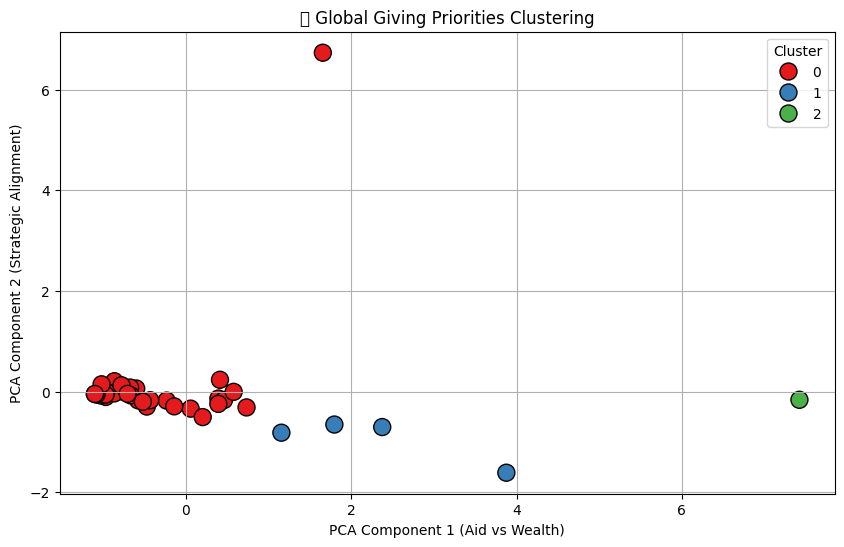

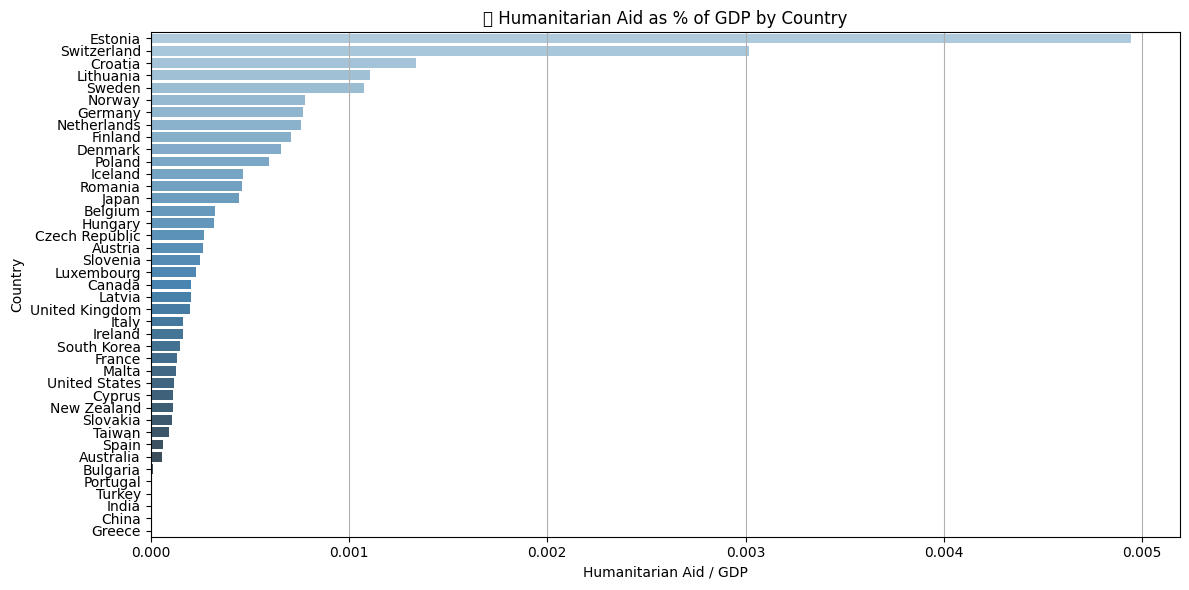

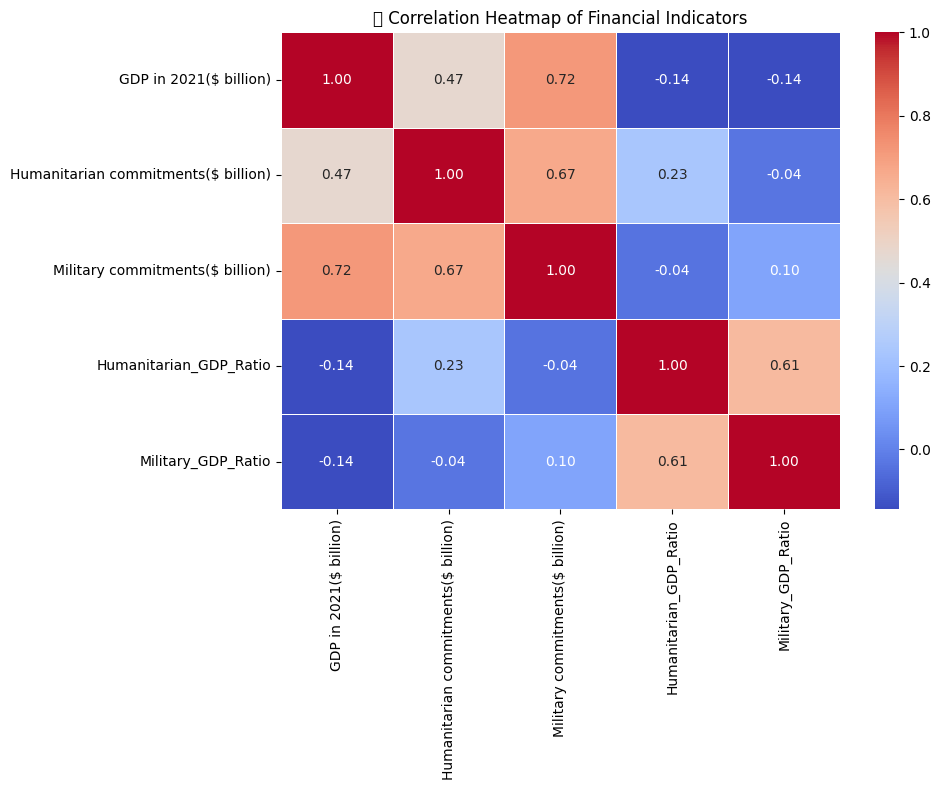

In [3]:
# 🌍 THE COST OF COMPASSION
# Modeling Global Charitable vs Military Priorities

# === STEP 1: IMPORT LIBRARIES ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

# === STEP 2: UPLOAD FILES ===
uploaded = files.upload()  # Upload 'Financial Allocations.csv' and 'Financial Commitments.csv'

# === STEP 3: LOAD AND MERGE DATA ===
allocations = pd.read_csv('Financial Allocations.csv')
commitments = pd.read_csv('Financial Commitments.csv')
df = pd.merge(allocations, commitments, on=['Country', 'EU member'])

# === STEP 4: FEATURE ENGINEERING ===
df['Humanitarian_GDP_Ratio'] = df['Humanitarian commitments($ billion)'] / df['GDP in 2021($ billion)']
df['Military_GDP_Ratio'] = df['Military commitments($ billion)'] / df['GDP in 2021($ billion)']
df['Total_GDP_Ratio'] = df['Total bilateral commitments($ billion)'] / df['GDP in 2021($ billion)']
df['Humanitarian_to_Military_Ratio'] = df['Humanitarian commitments($ billion)'] / (df['Military commitments($ billion)'] + 1e-6)

# === STEP 5: KMEANS CLUSTERING ===
features = df[['Humanitarian_GDP_Ratio', 'Military_GDP_Ratio', 'Total_GDP_Ratio', 'Humanitarian_to_Military_Ratio']]
scaled = StandardScaler().fit_transform(features)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

# === STEP 6: PCA VISUALIZATION ===
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=df['Cluster'], palette='Set1', s=150, edgecolor='black')
plt.title("🧭 Global Giving Priorities Clustering")
plt.xlabel("PCA Component 1 (Aid vs Wealth)")
plt.ylabel("PCA Component 2 (Strategic Alignment)")
plt.grid(True)
plt.show()

# === STEP 7: HUMANITARIAN AID AS % OF GDP ===
plt.figure(figsize=(12, 6))
sns.barplot(data=df.sort_values('Humanitarian_GDP_Ratio', ascending=False),
            x='Humanitarian_GDP_Ratio', y='Country', palette='Blues_d')
plt.title("🌍 Humanitarian Aid as % of GDP by Country")
plt.xlabel("Humanitarian Aid / GDP")
plt.ylabel("Country")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# === STEP 8: ANNOTATED BUBBLE CHART ===
fig_bubble = px.scatter(
    df,
    x="Humanitarian commitments($ billion)",
    y="Military commitments($ billion)",
    size="GDP in 2021($ billion)",
    color="Cluster",
    hover_name="Country",
    text="Country",
    size_max=60,
    title="🌐 Humanitarian vs Military Aid (Bubble Size = GDP)"
)
fig_bubble.update_traces(textposition='top center')
fig_bubble.update_layout(
    xaxis_title="Humanitarian Commitments ($B)",
    yaxis_title="Military Commitments ($B)",
    legend_title="Cluster",
    template="plotly_white"
)
fig_bubble.show()

# === STEP 9: CORRELATION HEATMAP ===
plt.figure(figsize=(10, 8))
financial_cols = [
    'GDP in 2021($ billion)',
    'Humanitarian commitments($ billion)',
    'Military commitments($ billion)',
    'Humanitarian_GDP_Ratio',
    'Military_GDP_Ratio'
]
sns.heatmap(df[financial_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("📈 Correlation Heatmap of Financial Indicators")
plt.tight_layout()
plt.show()

# === STEP 10: INTERACTIVE TABLE DASHBOARD ===
fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(df.columns), fill_color='paleturquoise', align='left'),
    cells=dict(values=[df[col] for col in df.columns], fill_color='lavender', align='left'))
])
fig_table.update_layout(title="🌍 Interactive Dashboard: Country Financial Commitments")
fig_table.show()
